# PAT + Gradient Ascent Registration

This notebook compares three registration strategies:

| Strategy | Description |
|----------|-------------|
| **A** | Gradient ascent (GA) from identity initialisation (baseline) |
| **B** | Principal Axes Transform (PAT) standalone - no optimisation |
| **C** | PAT initialisation followed by GA refinement |

In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../code')

import numpy as np
import matplotlib.pyplot as plt
import registration as reg
import registration_util as util
import PAT_util as pat 

---
## Section 1 — Load images

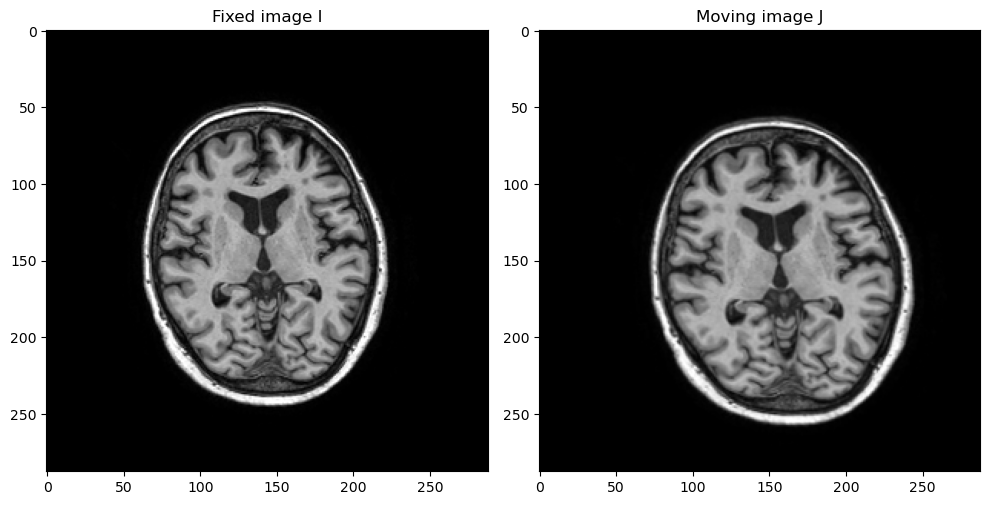

In [3]:
I   = plt.imread('../data/image_data/3_2_t1.tif').astype(np.float64)   # fixed
J   = plt.imread('../data/image_data/3_2_t1_d.tif').astype(np.float64) # moving

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(I, cmap='gray')
axes[0].set_title('Fixed image I')
axes[1].imshow(J, cmap='gray')
axes[1].set_title('Moving image J')
plt.tight_layout()
plt.show()

---
## Section 2 — Implement functions

### 2a — `parameter vector → homogeneous matrix`

In [4]:
# SCALING = 100  
# NUM_BINS = 64

def params_to_Th(x):
    """
    Convert parameter vector x = [angle, scale_x, scale_y, shear_x, shear_y, translation_x, translation_y] to a
    homogeneous affine transformation matrix Th.
    """
    phi = x[0] # Rotation angle
    sx, sy = x[1], x[2] # Scaling factors
    shx, shy = x[3], x[4]# Shearing factors
    tx, ty = x[5], x[6] # Translation factors

    # We generate each component and compose the linear transformation matrix
    R = reg.rotate(phi)
    Sh = reg.shear(shx, shy)
    S = np.array([[sx, 0], [0, sy]])
    
    A = Sh@S@R

    # We then create the homoeneous function
    Th = util.t2h(A, np.array([[tx], [ty]]))
    return Th

### 2b — `gradient_ascent_registration`

Performs gradient **ascent** (maximising the similarity score) using the numerical gradient from `ngradient`.  The update rule at each step is:

$$\mathbf{x} \leftarrow \mathbf{x} + \eta \, \nabla_x f(\mathbf{x})$$

where $\eta$ is the learning rate and $f$ is the similarity function.

In [5]:
def gradient_ascent_registration(I, J, x_init, similarity_fn,
                                   n_iterations=50, learning_rate=1e-3, tol=1e-4):
    """
    Intensity-based registration via gradient ascent on similarity_fn.

    Parameters
    ----------
    I, J          : fixed and moving images 
    x_init        : initial parameter vector [rot angle, sx, sy, shx, shy, tx, ty]
    similarity_fn : similarity function
    n_iterations  : number of gradient ascent steps
    learning_rate : step size
    tol           : convergence tolerance for similarity change

    Returns
    -------
    x_opt   : final parameter vector
    history : list of similarity scores, one per iteration
    """
    x = x_init.copy().astype(np.float64)
    history = []

    current_sim = similarity_fn(x)
    history.append(current_sim)

    print(f'  Initial similarity : {current_sim:.4f}')
    print(f'  Initial parameters : angle={np.degrees(x[0]):.2f} deg, '
          f'sx={x[1]:.4f}, sy={x[2]:.4f}, shx={x[3]:.4f}, shy={x[4]:.4f}, tx={x[5]:.4f}, ty={x[6]:.4f}')

    for i in range(n_iterations):
         g = reg.ngradient(similarity_fn, x)
         step = learning_rate * g
         x = x + step

         new_sim = similarity_fn(x)
         history.append(new_sim)
       
         sim_change = abs(new_sim - current_sim)
         if sim_change < tol:
            print(f' Converged at iteration {i+1}')
            break
        
         current_sim = new_sim

    print(f'  Final similarity   : {history[-1]:.4f}')
    print(f'  Final parameters   : angle={np.degrees(x[0]):.2f} deg, '
          f'sx={x[1]:.4f}, sy={x[2]:.4f}, shx={x[3]:.4f}, shy={x[4]:.4f}, tx={x[5]:.4f}, ty={x[6]:.4f}')
    return x, history

---
## Section 3 — Run registration strategies

All three strategies are applied to the same image pair.  Strategies A and C share the same number of iterations and learning rate.

In [6]:
# Shared hyper-parameters for gradient ascent
N_ITER = 50
LR     = 1e-3

# Similarity function shared by strategies A and C
similarity_fn = lambda x: reg.affine_mi(I, J, x, return_transform=False)

In [7]:
print('=== Strategy A: Gradient ascent from identity ===')
x_init_identity = np.array([0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0])

x_opt_A, history_A = gradient_ascent_registration(
    I, J, x_init_identity, similarity_fn,
    n_iterations=N_ITER, learning_rate=LR
)

Th_A           = params_to_Th(x_opt_A)
J_registered_A, _ = reg.image_transform(J, Th_A)

=== Strategy A: Gradient ascent from identity ===
  Initial similarity : 0.3749
  Initial parameters : angle=0.00 deg, sx=1.0000, sy=1.0000, shx=0.0000, shy=0.0000, tx=0.0000, ty=0.0000
  Final similarity   : 0.5970
  Final parameters   : angle=-0.31 deg, sx=1.0785, sy=1.0315, shx=0.0393, shy=0.0333, tx=0.0004, ty=0.0003


In [8]:
print('=== Strategy B: PAT standalone ===')
Th_B           = pat.principal_axes_transform(I, J)
J_registered_B, _ = reg.image_transform(J, Th_B)

# Extract the parameters encoded in Th_B so they can seed Strategy C.
angle_B = np.arctan2(Th_B[1, 0], Th_B[0, 0])
tx_B    = Th_B[0, 2] # / SCALING
ty_B    = Th_B[1, 2] # / SCALING

print(f'Parameters : angle={np.degrees(angle_B):.2f} deg, '
      f'tx={tx_B:.4f}, ty={ty_B:.4f}')

=== Strategy B: PAT standalone ===
Rotation angle: 0.1535 rad  (8.79 deg)
Parameters : angle=-8.79 deg, tx=-5.9635, ty=34.4579


In [9]:
print('=== Strategy C: PAT initialisation + gradient ascent ===')
x_init_pat = np.array([angle_B, 1.0, 1.0, 0.0, 0.0, tx_B, ty_B])

x_opt_C, history_C = gradient_ascent_registration(
    I, J, x_init_pat, similarity_fn,
    n_iterations=N_ITER, learning_rate=LR
)

Th_C           = params_to_Th(x_opt_C)
J_registered_C, _ = reg.image_transform(J, Th_C)

=== Strategy C: PAT initialisation + gradient ascent ===
  Initial similarity : 0.5588
  Initial parameters : angle=-8.79 deg, sx=1.0000, sy=1.0000, shx=0.0000, shy=0.0000, tx=-5.9635, ty=34.4579
  Final similarity   : 0.6191
  Final parameters   : angle=-8.72 deg, sx=1.0310, sy=1.0234, shx=-0.0194, shy=-0.0184, tx=-5.9637, ty=34.4576


---
## Section 4 — Visual comparison of registration

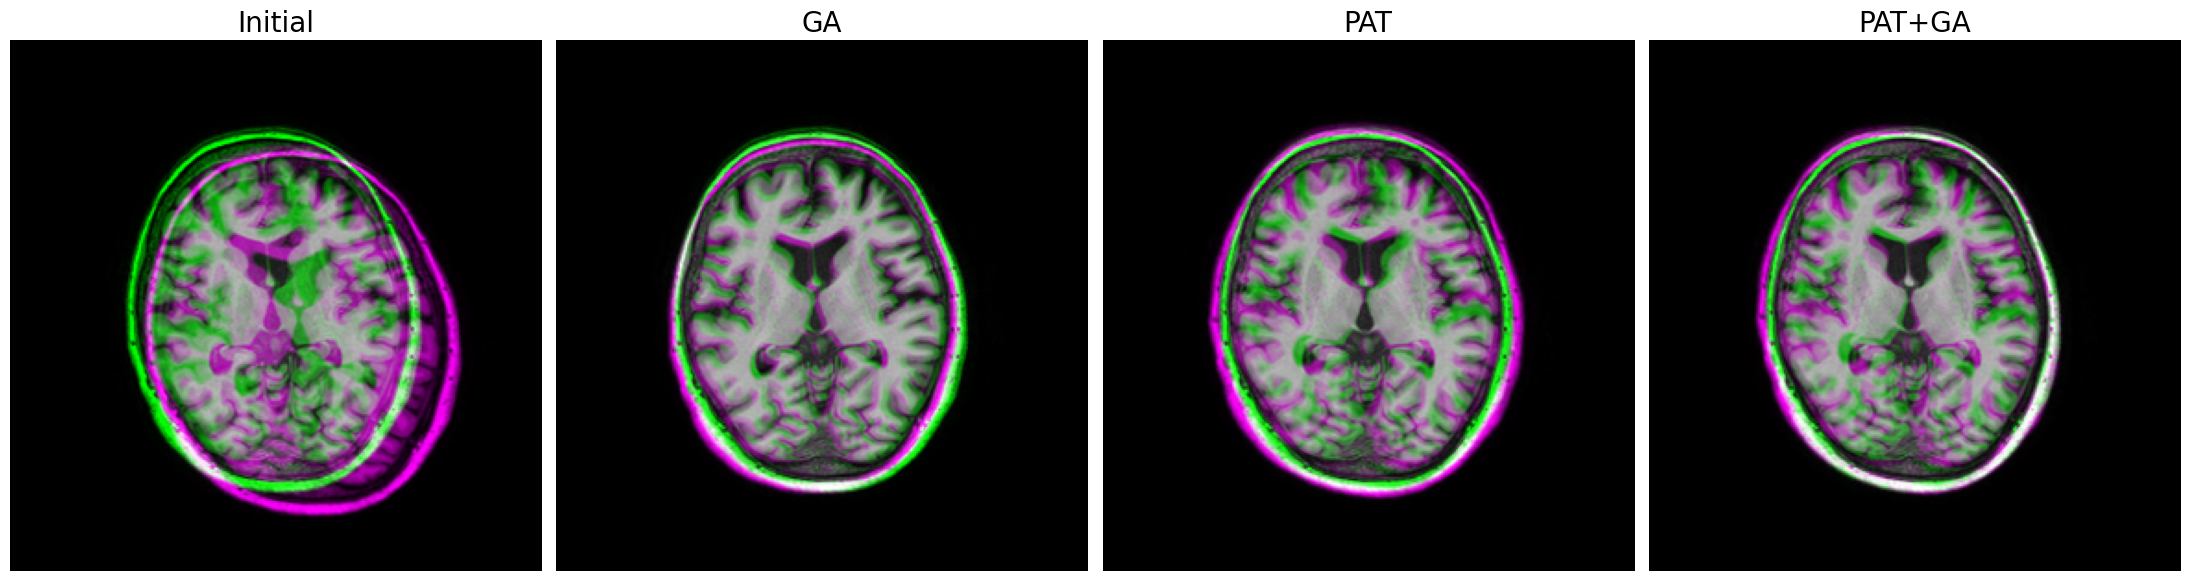

In [10]:
diff_J   = pat.color_overlay(I,J)
diff_A   = pat.color_overlay(I, J_registered_A)
diff_B   = pat.color_overlay(I, J_registered_B)
diff_C   = pat.color_overlay(I, J_registered_C)

fig, axes = plt.subplots(1, 4, figsize=(22, 10))

imgs   = [diff_J, diff_A, diff_B, diff_C]
titles = ['Initial', 'GA', 'PAT', 'PAT+GA']

for col_idx, (img, title) in enumerate(zip(imgs, titles)):
    axes[col_idx].imshow(img)
    axes[col_idx].set_title(title, fontsize=20)
    axes[col_idx].axis('off') 

plt.tight_layout()
plt.show()

---
## Section 5 — Convergence plot

We plot the MI similarity score at every gradient-ascent iteration for Strategy A (identity init) and Strategy C (PAT init).  The horizontal dashed line marks the MI achieved by Strategy B (PAT alone, zero iterations).

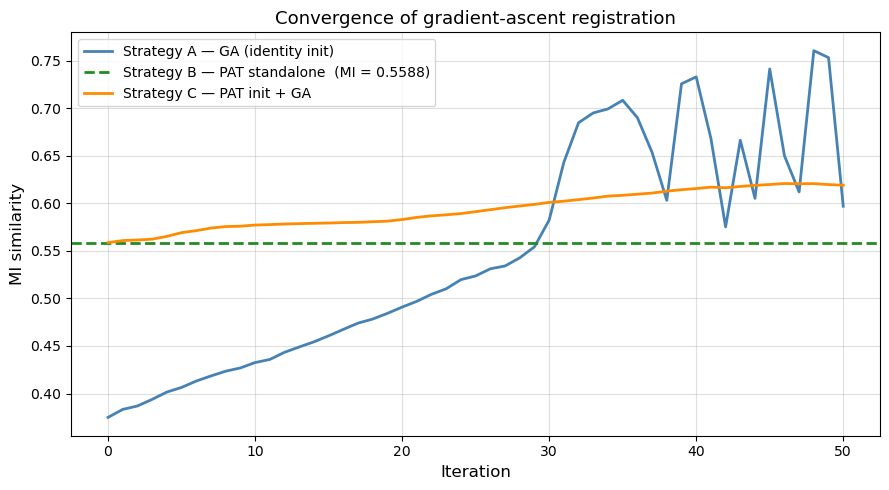

In [11]:
hist_B = reg.joint_histogram(I, J_registered_B) 
mi_B = reg.mutual_information(hist_B) 

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(range(len(history_A)), history_A, color='steelblue',  lw=2, label='Strategy A — GA (identity init)')
ax.axhline(mi_B, color='forestgreen', lw=2, linestyle='--',
           label=f'Strategy B — PAT standalone  (MI = {mi_B:.4f})')
ax.plot(range(len(history_C)), history_C, color='darkorange', lw=2, label='Strategy C — PAT init + GA')

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('MI similarity', fontsize=12)
ax.set_title('Convergence of gradient-ascent registration', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

---
## Section 6 — Quantitative evaluation

In [12]:
def compute_metrics(fixed, registered):
    ncc = reg.correlation(fixed, registered)
    mi  = reg.mutual_information(reg.joint_histogram(fixed, registered))
    return ncc, mi

ncc_before, mi_before = compute_metrics(I, J)
ncc_A,      mi_A      = compute_metrics(I, J_registered_A)
ncc_B_val,  mi_B      = compute_metrics(I, J_registered_B)
ncc_C,      mi_C      = compute_metrics(I, J_registered_C)

header = f"{'Strategy':<35} {'NCC':>8}  {'MI ':>10}"
sep    = '=' * len(header)
print(sep)
print(header)
print('-' * len(header))
print(f"{'Unregistered ':<35} {ncc_before:>8.4f}  {mi_before:>10.4f}")
print(f"{'A — GA from identity':<35} {ncc_A:>8.4f}  {mi_A:>10.4f}")
print(f"{'B — PAT standalone':<35} {ncc_B_val:>8.4f}  {mi_B:>10.4f}")
print(f"{'C — PAT init + GA refinement':<35} {ncc_C:>8.4f}  {mi_C:>10.4f}")
print(sep)

Strategy                                 NCC         MI 
--------------------------------------------------------
Unregistered                          0.5994      0.3749
A — GA from identity                  0.8112      0.5970
B — PAT standalone                    0.7328      0.5588
C — PAT init + GA refinement          0.8411      0.6191
